In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings


# Load your data (adjust path)
df= pd.read_csv(r"C:\Users\mahla\Downloads\DataSets\CleanedSpeakersData.csv")

print("✅ Data loaded successfully")
print(f"Shape: {df.shape}")


✅ Data loaded successfully
Shape: (30000, 24)



📊Funnel Chart...


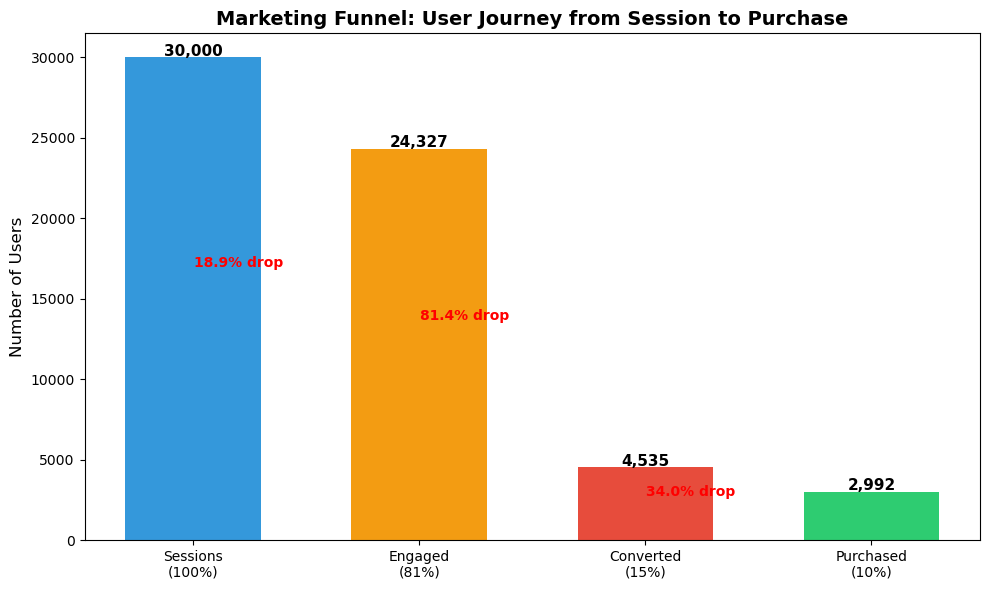

In [3]:
# 1. FUNNEL CHART - Show drop-offs
print("\n📊Funnel Chart...")

# Calculate funnel values
sessions = len(df)
engaged = df[df['bounce_flag'] == 0].shape[0]
converted = df[df['conversion_flag'] == 1].shape[0]
purchased = df[df['conversion_type'] == 'Purchase'].shape[0]

stages = ['Sessions\n(100%)', f'Engaged\n({(engaged/sessions)*100:.0f}%)', 
          f'Converted\n({(converted/sessions)*100:.0f}%)', f'Purchased\n({(purchased/sessions)*100:.0f}%)']
values = [sessions, engaged, converted, purchased]
colors = ['#3498db', '#f39c12', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(stages, values, color=colors, width=0.6)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Marketing Funnel: User Journey from Session to Purchase', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100, f'{val:,}', 
            ha='center', fontweight='bold', fontsize=11)

# Add drop-off annotations
drop1 = ((sessions - engaged)/sessions)*100
drop2 = ((engaged - converted)/engaged)*100
drop3 = ((converted - purchased)/converted)*100

ax.annotate(f'{drop1:.1f}% drop', xy=(0, sessions/2), xytext=(0.2, sessions/2 + 2000), 
            ha='center', color='red', fontweight='bold')
ax.annotate(f'{drop2:.1f}% drop', xy=(1, engaged/2), xytext=(1.2, engaged/2 + 1500), 
            ha='center', color='red', fontweight='bold')
ax.annotate(f'{drop3:.1f}% drop', xy=(2, converted/2), xytext=(2.2, converted/2 + 500), 
            ha='center', color='red', fontweight='bold')

plt.tight_layout()



📊Channel Performance Chart...


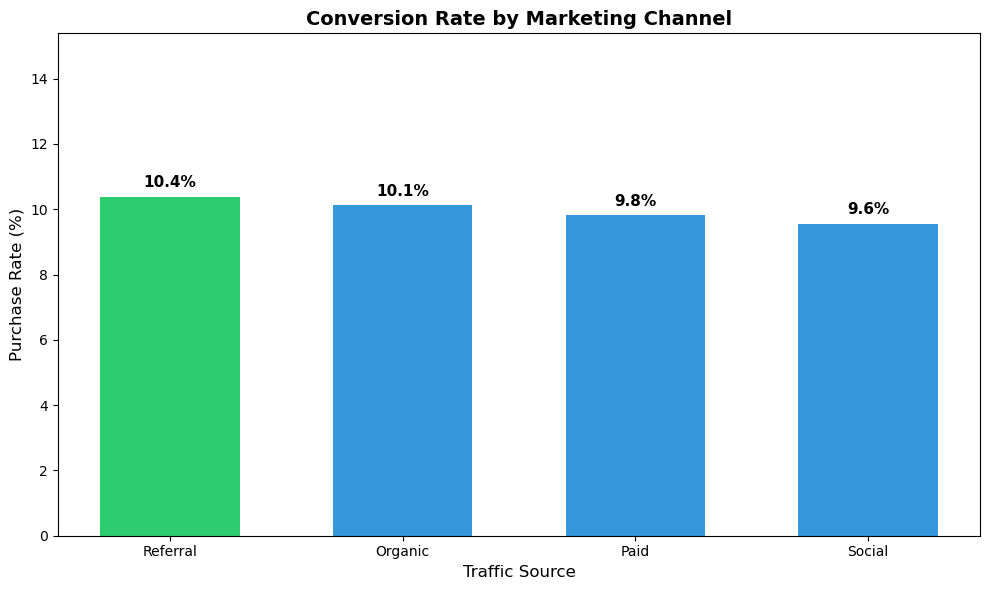

In [7]:
# 2. CHANNEL PERFORMANCE - Purchase rate by traffic source
print("\n📊Channel Performance Chart...")

channel_perf = df.groupby('traffic_source').apply(
    lambda x: (x['conversion_type'] == 'Purchase').sum() / len(x) * 100,
    include_groups=False
).sort_values(ascending=False)

colors_channel = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(channel_perf))]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(channel_perf.index, channel_perf.values, color=colors_channel, width=0.6)
ax.set_ylabel('Purchase Rate (%)', fontsize=12)
ax.set_xlabel('Traffic Source', fontsize=12)
ax.set_title('Conversion Rate by Marketing Channel', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(channel_perf.values) + 5)

for bar, rate in zip(bars, channel_perf.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{rate:.1f}%', 
            ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()



📊Revenue Distribution Chart...


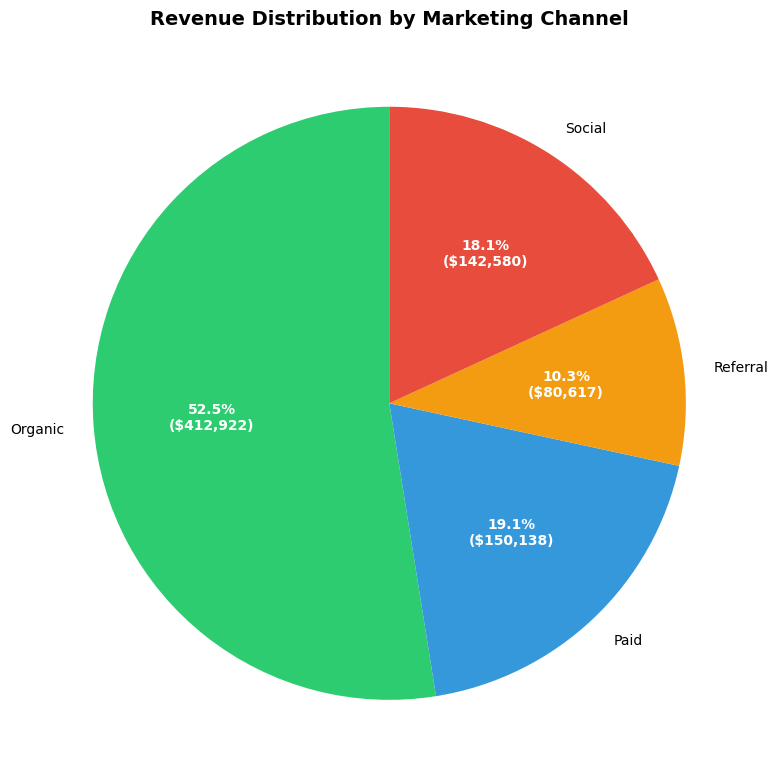

In [9]:
# 3. REVENUE DISTRIBUTION - Pie chart
print("\n📊Revenue Distribution Chart...")

revenue_by_channel = df.groupby('traffic_source')['revenue_$'].sum()
colors_pie = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(revenue_by_channel, labels=revenue_by_channel.index, 
                                   autopct=lambda pct: f'{pct:.1f}%\n(${pct/100*revenue_by_channel.sum():,.0f})',
                                   colors=colors_pie, startangle=90)
ax.set_title('Revenue Distribution by Marketing Channel', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.tight_layout()



📊Pages Visited Analysis...


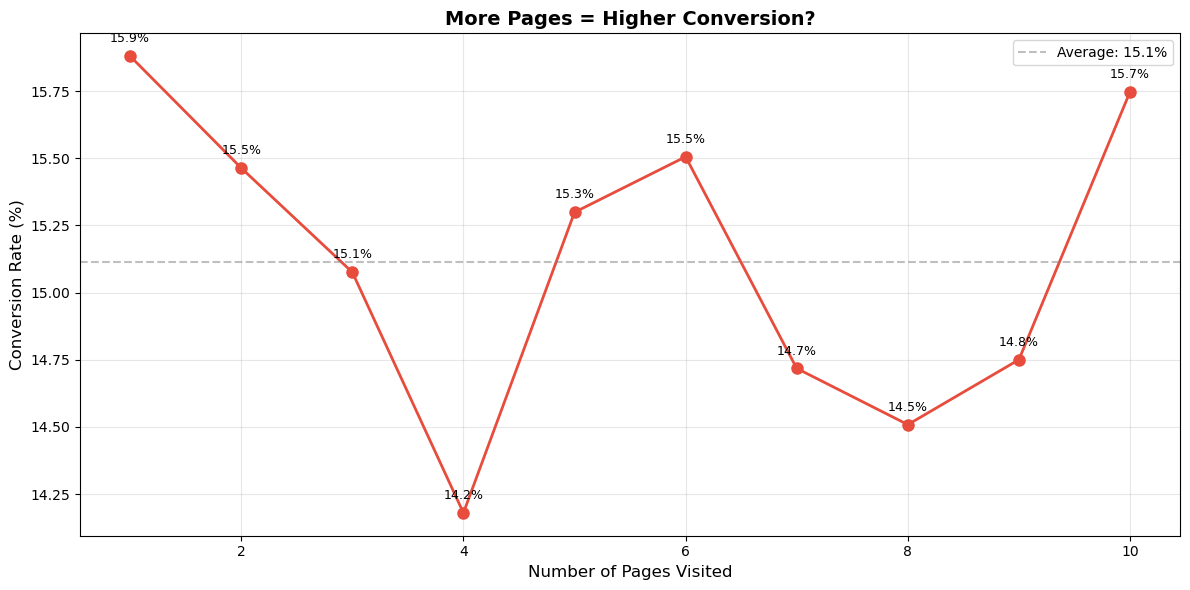

In [11]:
# 4. PAGES VISITED - Line chart
print("\n📊Pages Visited Analysis...")

pages_data = df.groupby('pages_visited').agg({
    'conversion_flag': 'mean',
    'session_id': 'count'
}).reset_index()
pages_data['conversion_rate'] = pages_data['conversion_flag'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pages_data['pages_visited'], pages_data['conversion_rate'], 
        marker='o', linewidth=2, markersize=8, color='#e74c3c')
ax.axhline(y=pages_data['conversion_rate'].mean(), color='gray', linestyle='--', 
           alpha=0.5, label=f'Average: {pages_data["conversion_rate"].mean():.1f}%')
ax.set_xlabel('Number of Pages Visited', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('More Pages = Higher Conversion?', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

for _, row in pages_data.iterrows():
    ax.annotate(f'{row["conversion_rate"]:.1f}%', (row['pages_visited'], row['conversion_rate']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()



📊 Creating Device Performance Chart...


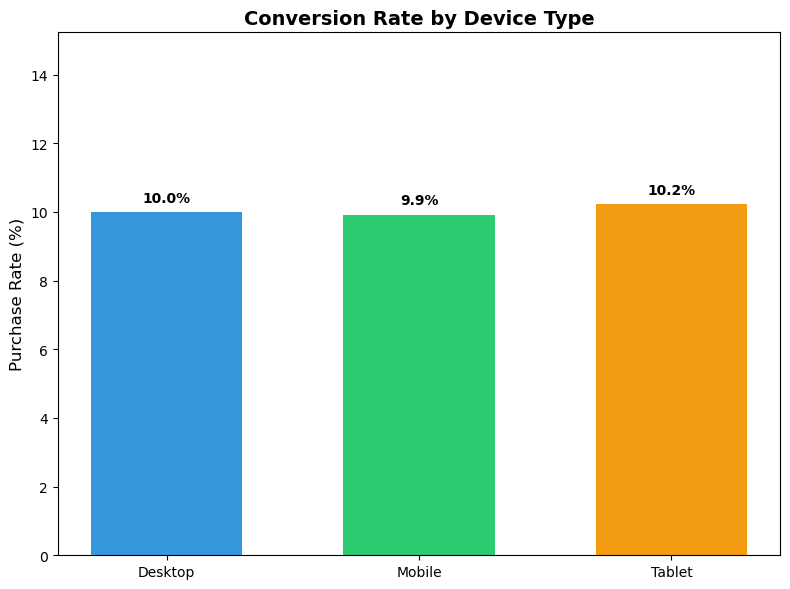

✅ Saved: 05_device_performance.png


In [12]:
# 5. DEVICE PERFORMANCE - Grouped bar chart
print("\n📊 Device Performance Chart")

device_metrics = df.groupby('device_type').agg({
    'conversion_type': lambda x: (x == 'Purchase').sum(),
    'session_id': 'count'
})
device_metrics['purchase_rate'] = (device_metrics['conversion_type'] / device_metrics['session_id']) * 100

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(device_metrics.index, device_metrics['purchase_rate'], color=['#3498db', '#2ecc71', '#f39c12'], width=0.6)
ax.set_ylabel('Purchase Rate (%)', fontsize=12)
ax.set_title('Conversion Rate by Device Type', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(device_metrics['purchase_rate']) + 5)

for bar, (device, row) in zip(bars, device_metrics.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, 
            f'{row["purchase_rate"]:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('05_device_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 05_device_performance.png")


📊Demographic Analysis...


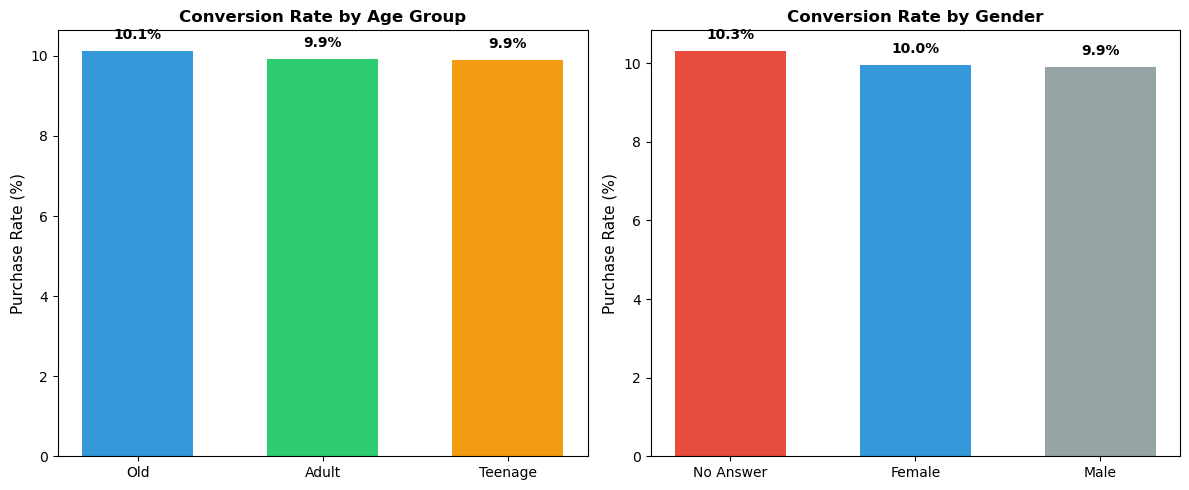

In [15]:
# 6. DEMOGRAPHIC ANALYSIS - Grouped bar chart
print("\n📊Demographic Analysis...")

# Age group performance
age_perf = df.groupby('demographic_age_group').apply(
    lambda x: (x['conversion_type'] == 'Purchase').sum() / len(x) * 100,
    include_groups=False
).sort_values(ascending=False)

# Gender performance
gender_perf = df.groupby('demographic_gender').apply(
    lambda x: (x['conversion_type'] == 'Purchase').sum() / len(x) * 100,
    include_groups=False
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age group bar chart
colors_age = ['#3498db', '#2ecc71', '#f39c12']
bars1 = axes[0].bar(age_perf.index, age_perf.values, color=colors_age, width=0.6)
axes[0].set_ylabel('Purchase Rate (%)', fontsize=11)
axes[0].set_title('Conversion Rate by Age Group', fontweight='bold')
for bar, rate in zip(bars1, age_perf.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{rate:.1f}%', 
                 ha='center', fontweight='bold')

# Gender bar chart
colors_gender = ['#e74c3c', '#3498db', '#95a5a6']
bars2 = axes[1].bar(gender_perf.index, gender_perf.values, color=colors_gender, width=0.6)
axes[1].set_ylabel('Purchase Rate (%)', fontsize=11)
axes[1].set_title('Conversion Rate by Gender', fontweight='bold')
for bar, rate in zip(bars2, gender_perf.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{rate:.1f}%', 
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('06_demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



📊Engagement Heatmap...


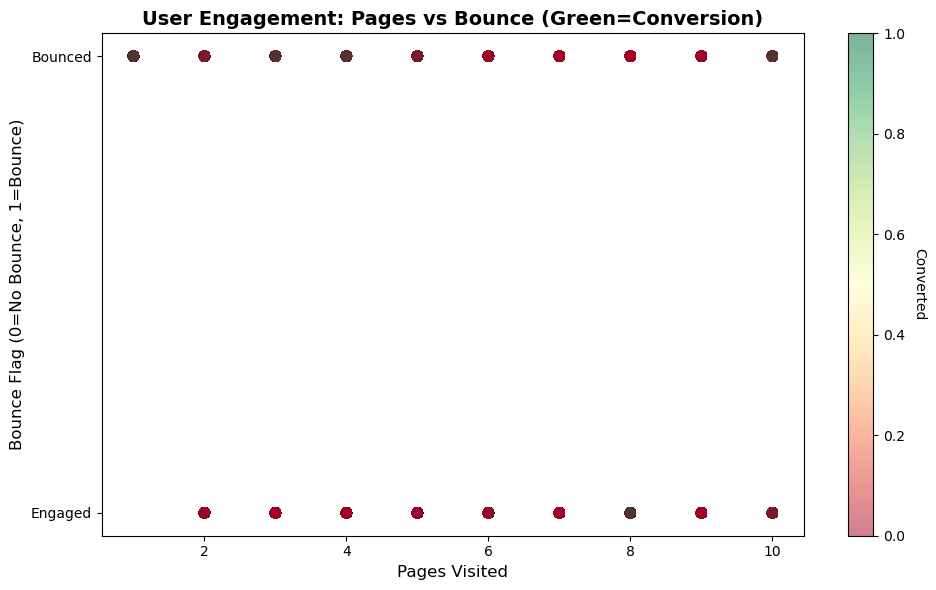

In [16]:
# 7. ENGAGEMENT HEATMAP - Pages vs Bounce
print("\n📊Engagement Heatmap...")

# Create pivot table for heatmap
heatmap_data = df.groupby(['pages_visited', 'bounce_flag']).size().unstack(fill_value=0)
heatmap_data['bounce_percent'] = (heatmap_data[1] / (heatmap_data[0] + heatmap_data[1])) * 100

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['pages_visited'], df['bounce_flag'], 
                     c=df['conversion_flag'], cmap='RdYlGn', alpha=0.5, s=50)
ax.set_xlabel('Pages Visited', fontsize=12)
ax.set_ylabel('Bounce Flag (0=No Bounce, 1=Bounce)', fontsize=12)
ax.set_title('User Engagement: Pages vs Bounce (Green=Conversion)', fontsize=14, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Engaged', 'Bounced'])
cbar = plt.colorbar(scatter)
cbar.set_label('Converted', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('07_engagement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()



📊Geographic Performance Chart


C:\Users\mahla\AppData\Local\Temp\ipykernel_19688\834032428.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_perf = df.groupby('country').apply(


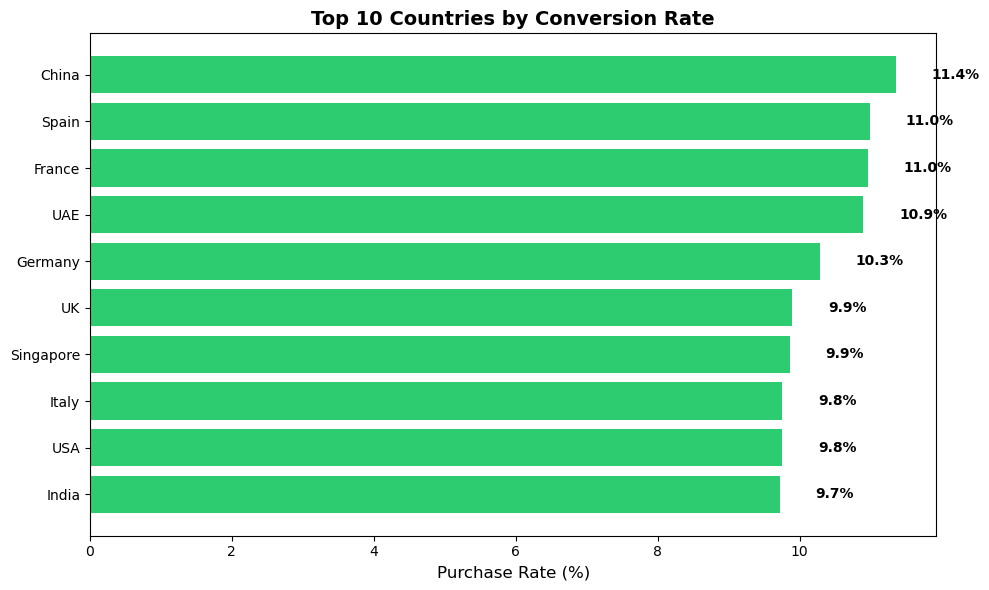

In [17]:
# 8. GEOGRAPHIC PERFORMANCE - Top countries
print("\n📊Geographic Performance Chart")

country_perf = df.groupby('country').apply(
    lambda x: (x['conversion_type'] == 'Purchase').sum() / len(x) * 100
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(country_perf)), country_perf.values, color='#2ecc71')
ax.set_yticks(range(len(country_perf)))
ax.set_yticklabels(country_perf.index)
ax.set_xlabel('Purchase Rate (%)', fontsize=12)
ax.set_title('Top 10 Countries by Conversion Rate', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (country, rate) in enumerate(country_perf.items()):
    ax.text(rate + 0.5, i, f'{rate:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('08_geographic_performance.png', dpi=150, bbox_inches='tight')
plt.show()
